In [1]:
import sys
sys.path.insert(1,'/home/leon/Software/magpy/') # should be magpy2
sys.path.insert(1,'/home/leon/Software/IMBOT/') # should be magpy2

from magpy.stream import *
from magpy.core import activity as act
from magpy.core import plot as mp
from magpy.core import flagging
from magpy.core.methods import dictdiff, testtime
from imbot.core import methods
from imbot.core import steps
from imbot.core import report

import copy
# Remove that
import matplotlib.pyplot as plt
plt.close('all')
matplotlib.use('TkAgg')
%matplotlib inline


In [ ]:
# Load configuration and initialize IMBOT module
# ----------------------------------------------
# --- PLEASE UPDATE THE PATH ---

config = methods.get_conf('/home/cobs/.imbot/conf/imbot.cfg')
imostatus = steps.botstatus(config=config)

In [2]:
# 1. Statistics
# ----------------------------------------------

secstats = imostatus.yearly_stats(resolution='second')
minstats = imostatus.yearly_stats(resolution='minute')

In [5]:
# 1.1 List observatories and levels
# ----------------------------------------------

ores = report.observatory_list(secstats, year=2022, levels=True)
print (ores)

In [6]:
print (ores)

IMO | Level
--- | -----
ABK | 2
ASP | 2
BEL | 2
BOU | 1
CKI | 2
CLF | 2
CMO | 2
CNB | 2
CSY | 2
CTA | 2
DED | 2
EBR | 2
FRN | 2
FUR | 2
GNG | 2
HER | 1
HLP | 2
HRN | 2
KAK | 2
KDU | 2
KNY | 2
LRM | 2
LYC | 2
MAW | 2
MCQ | 2
MMB | 2
SIT | 1
UPS | 2
WIC | 2



In [41]:
# 1.2 Get last uploads
# ----------------------------------------------

lastup = report.get_last_updates(minstats, startyear=1777)
print(lastup)

2000 |  
2016 | 2025-03-23T08:24:14
2022 | 2025-03-22T14:39:47
2023 |  



In [7]:
# 1.3 Storage statistics
# ----------------------------------------------

r = report.imbot_disk_usage(archive=None, warnlevel=20, critlevel=10)
print(r)

In [9]:
# 1.4 Checkout referees
# ----------------------------------------------
# use "assigned" to find observatories witout assigned referee
referee = 'Jan'
print (imostatus.referee_assignment(startyear=2016, resolution='second', referee=referee))


/home/leon/Tmp/GIN/conf
{'Jan Reda': ['BDV', 'BFO', 'HON', 'SIT', 'SJG', 'TTB', 'VNA']}


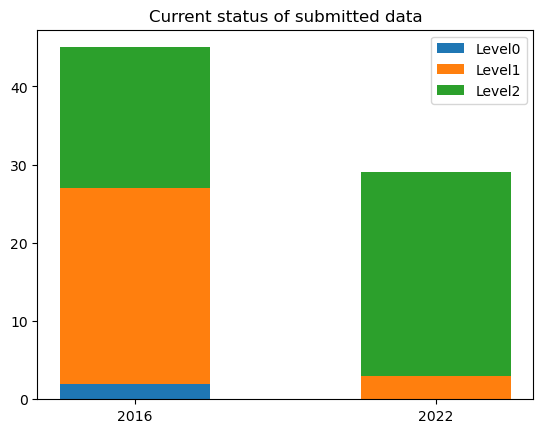

In [10]:
# 1.5 Plot yearly statistics
# ----------------------------------------------

# dsiplay can be "steps" or "level"
plt = report.yearly_stats(stats,display="level", years=['2016','2022'])
#plt.savefig("/home/leon/Software/IMBOT/imbot/documentation/bar_levels.png")

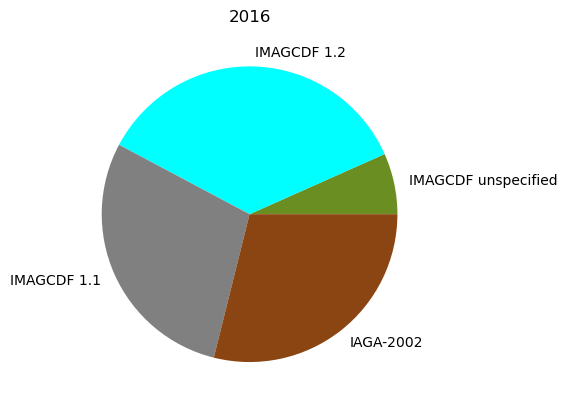

In [13]:

displaylist = ['INTERMAGNET CDF FORMAT; 1.X','INTERMAGNET CDF FORMAT; 1.2','INTERMAGNET CDF FORMAT; 1.1','IAGA-2002','INTERMAGNET CDF FORMAT; 1.3']
#displaylist = ["N_step1","N_step2","N_step2accepted","N_step3"]
#displaylist = ["Level0","Level1","Level2"]
year = 2016
p = report.pie_chart(stats, year, displaylist)
#p.savefig("/home/leon/Software/IMBOT/imbot/documentation/pie_{}_formats.png".format(year))

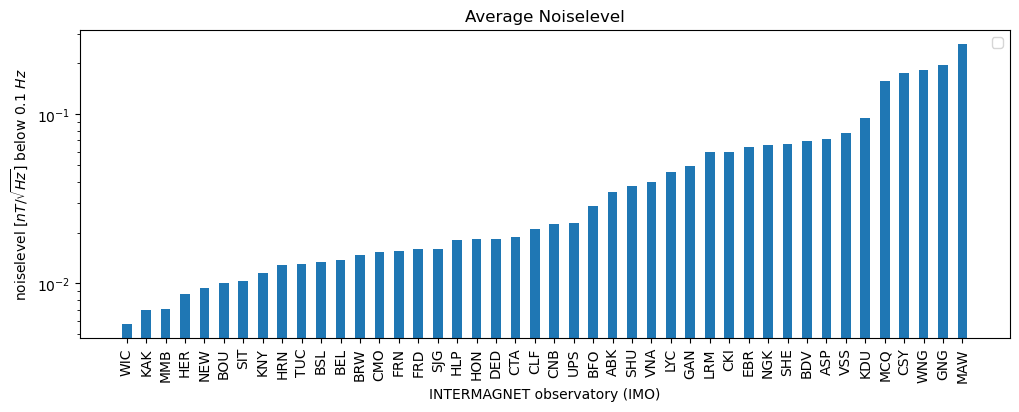

In [15]:
# Specific year - Noise
year=2016
plt = report.noiselevel_plot(stats, year=2016, debug=False)
#plt.show()
#plt.savefig("/home/leon/Software/IMBOT/imbot/documentation/noiselevel_{}.png".format(year))

In [33]:
# Agreement of step1 and step2
data1 = read("/home/leon/Tmp/GIN/step1second/2022_step1/CLF/clf_20220514_000000_PT1S_4.cdf")
data2 = read("/home/leon/Tmp/GIN/step2second/2022_step2/CLF/clf_202205_pt1s_4.cdf",starttime='2022-05-14',endtime='2022-05-15')

In [38]:
data3 = subtract_streams(data1,data2)

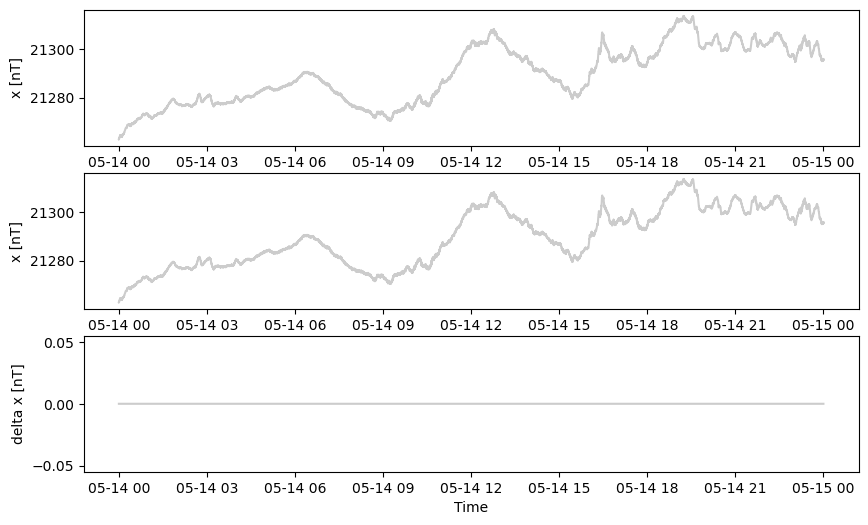

In [54]:
p,a = mp.tsplot([data1,data2,data3],[['x'],['x'],['x']], width=10, height=2)
p.savefig("/home/leon/Software/IMBOT/imbot/documentation/differences.png")

In [ ]:
# Test BDV 2016 - should report failures, redo CTA 2022 for Noise, what about SIT, BOU, ??? 2022; HER i level 1

# Plots for article:
# - submitted formats
# - achieved levels
# - currents steps
# - noise levels
# - comparison of step1 and step2 (equality of data and diffs of meta info)
# Tables
# - general submission status
# - overview analysis with dominant step1 and step0 reason


In [91]:
data = read("/home/leon/Tmp/GIN/step1second/2016/BDV/20160128.cdf")

In [92]:
t = data._remove_nancolumns()

In [93]:
len(t)

86400

(<Figure size 1000x1200 with 3 Axes>, <Axes: xlabel='Time', ylabel='z [nT]'>)

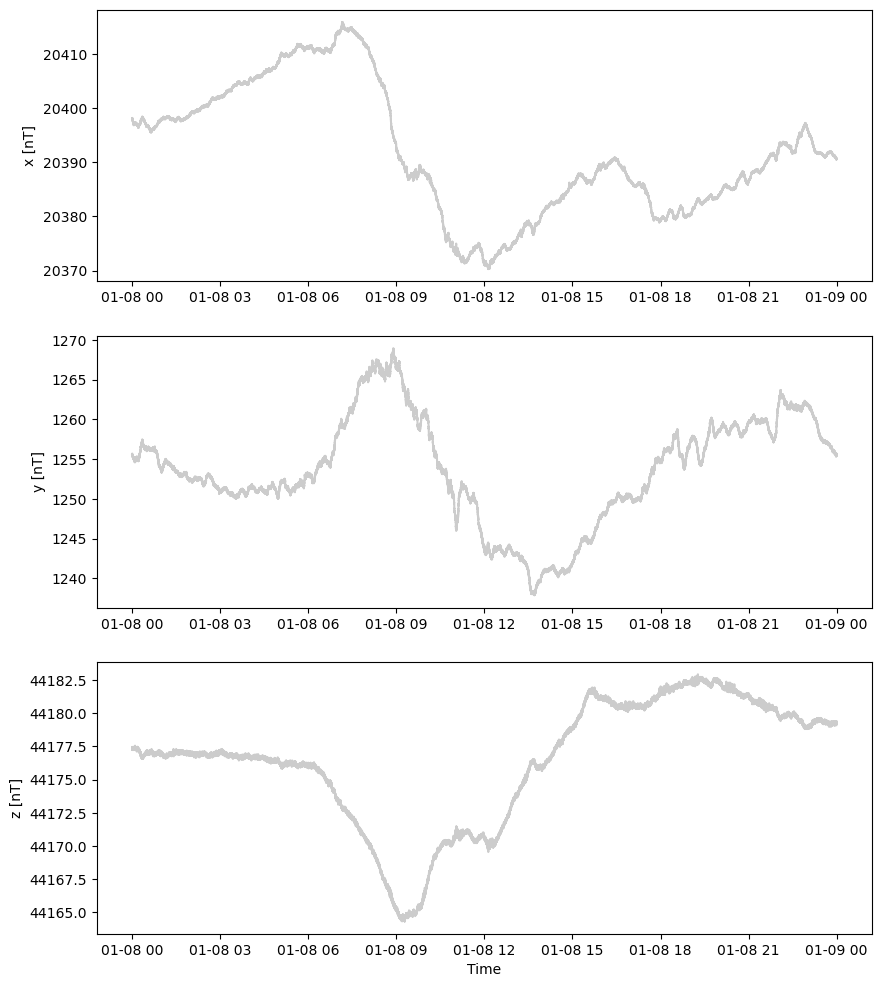

In [94]:
mp.tsplot(t)

In [2]:
# Test run
import os
import shutil
from imbot.core import methods
from imbot.core import steps
config = {}
# Create test environment in temporary directory
basepath = "/home/leon/Software/IMBOT/" # replace with __file__
os.makedirs(os.path.dirname("/tmp/imbottest"), exist_ok=True)
os.makedirs(os.path.dirname("/tmp/imbottest/minute/step1"), exist_ok=True)
os.makedirs(os.path.dirname("/tmp/imbottest/minute/step2"), exist_ok=True)
os.makedirs(os.path.dirname("/tmp/imbottest/minute/step3"), exist_ok=True)
if os.path.exists("/tmp/imbottest/minute/step1"):
    shutil.rmtree("/tmp/imbottest/minute/step1")
if os.path.exists("/tmp/imbottest/minute/step2"):
    shutil.rmtree("/tmp/imbottest/minute/step2")
if os.path.exists("/tmp/imbottest/minute/step3"):
    shutil.rmtree("/tmp/imbottest/minute/step3")
shutil.copytree(os.path.join(basepath,'test','step1'), "/tmp/imbottest/minute/step1")
shutil.copytree(os.path.join(basepath,'test','step1'), "/tmp/imbottest/minute/step2")
os.makedirs(os.path.dirname("/tmp/imbottest/conf"), exist_ok=True)
if os.path.exists("/tmp/imbottest/conf"):
    shutil.rmtree("/tmp/imbottest/conf")
shutil.copytree(os.path.join(basepath,'config'), "/tmp/imbottest/conf")
if os.path.exists("/tmp/imbottest/memory"):
    shutil.rmtree("/tmp/imbottest/memory")


FileNotFoundError: [Errno 2] No such file or directory: '/home/leon/Software/IMBOT/config'

In [4]:
from imbot.core import methods
from imbot.core import steps
config = methods.get_conf('/home/leon/Tmp/GIN/conf/imbot_test.cfg')
firstrun = False

# Starting preparations based on imbot_steps
imostatus = steps.botstatus(config=config) # allow for testrun which does not update operative imostatus


 memory path not found - please check (first run?)


In [7]:
imostatus.get_data_checker(obscode='XXX', year=2022, resolution='minute', debug=True)

CONF /home/leon/Tmp/GIN/conf
Fitting referee files: ['refereelist_minute.cfg']
Selected referee file: /home/leon/Tmp/GIN/conf/refereelist_minute.cfg
dictionary {'mona.musterfrau@mail.world': {'name': 'Mona Musterfrau', 'obslist': ['FUR', 'CNB', 'LYC']}, 'special1': {'name': 'Joe Doe', 'year': 2022, 'email': 'john.doe@example.com', 'obslist': ['FUR', 'XYZ']}, 'special2': {'name': 'Joe Doe', 'year': 2021, 'email': 'john.doe@example.com', 'obslist': 'XYZ'}, 'max.mustermann@mail.world': {'name': 'Max Mustermann'}}
mona.musterfrau@mail.world
special1
special2
max.mustermann@mail.world


{'Maxi Musti': 'maxi@example.com'}

In [6]:
imostatus.report

[]

In [3]:
"""
The Main directory analysistool

Will access valid original data paths (i.e. zip/tar etc) and create an information dictionary including mail addresses for
data checkers and observotory, current evaluation states, and content identifiers.
Will compare current state to a memory, and eventually add an analysis flag/ modified dictionary. Memory will always be updated with
current content (except for flags).
The analysisflag (and modified dict) will be reset when analyzed.

Will create a imostatus dictionary
"""

from imbot.core import methods
from imbot.core import steps
#config = methods.get_conf('')
config = {}
firstrun = False

# Starting preparations based on imbot_steps
imostatus = steps.botstatus(config=config) # allow for testrun which does not update operative imostatus
sourcepath = "/home/leon/Tmp/GIN/step1minute"
imostatus = imostatus.analyse_source(sourcepath, step=1, type='minute', debug=False)
sourcepath = "/home/leon/Tmp/GIN/step1second"
imostatus = imostatus.analyse_source(sourcepath, step=1, type='second', debug=False)

yearlist = [el for el in imostatus.result]
for year in yearlist:
    for restype in ['minute','second']:
        obsdata = imostatus.result.get(year).get(restype)
        if obsdata:
            obslist = [el for el in obsdata]
            for obs in obslist:
                print (obs, restype, year)
                imolayer = obsdata.get(obs)
                imolayer = imostatus._get_step1_information(imolayer, obscode=obs, debug=False)
                imostatus = imostatus.set_contacts(year=year, resolution=restype, obscode=obs)
                if firstrun:
                    # reset all inputs, remove "new" flags
                    imostatus = imostatus.set_modification(set='', year=year, resolution=restype, obscode=obs)
            imostatus = imostatus.update_validity(year=year, resolution=restype, excludeobs=['CNB','XYZ'])

methods.write_memory(imostatus.result, path=imostatus.config.get('memory_directory_analysis'),debug=True)

print ("Preparation finished:", imostatus.result)


 memory path not found - please check (first run?)
CNB minute 2022
 memory path not found - please check (first run?)
LYC minute 2022
FUR minute 2022
CNB second 2022
LYC second 2022
FUR second 2022
 writing memory files to /tmp/imbottest/memory/memory_directory_analysis.json
Preparation finished: {'2022': {'minute': {'CNB': {'step1': '/home/leon/Tmp/GIN/step1minute/Mag2022/CNB', 'filetype': '.bin', 'lastmodified': '2025-02-25T19:46:21', 'maximum_minute_step': 'step1', 'files': {'cnb22apr.bin': '20250225', 'cnb22aug.bin': '20250225', 'readme.cnb': '20250225', 'cnb22jun.bin': '20250225', 'cnb2022.blv': '20250225', 'cnb22mar.bin': '20250225', 'report22.cnb': '20250225', 'cnb22jan.bin': '20250225', 'cnb22jul.bin': '20250225', 'cnb22oct.bin': '20250225', 'cnb22nov.bin': '20250225', 'cnb22may.bin': '20250225', 'cnb22feb.bin': '20250225', 'yearmean.cnb': '20250225', 'cnb22dec.bin': '20250225', 'cnb22sep.bin': '20250225'}, 'exclude': True, 'statusid': '335395640400859581581912', 'modification'

In [4]:
"""
Preparations for analysis

Get the "current status" memory an extract modified data sets. Update "minute" states for modified one-second data and 
limit the amount of data sets to be treated,

Will create a modification list out of the imostatus dictionary
"""

# get all (year, resolution, obscode) with modification flags
modlist = imostatus.get_modified()
# Now copy data to be analzed to a temporary directory (why? because some data is packed/zipped/tared) only second?
modificationlist = methods.copy_temporary(modlist, debug=False)
# Please note: modificationlist will only contain new/update flags. step2/step3 additions will be dropped as they are not analyzed
# Final preparations: limit the amount of second data sets treated in this run and add current 
# maximum minute state+path to second analyses
modificationlist = imostatus.add_minute_state(modificationlist, debug=False)
modificationlist = methods.limit_second_obs(modificationlist, limit=3, debug=False)


Copying minute data from CNB,2022 to temporary folder /tmp/imbottest/unpacked/2022/minute/CNB
 -> Done ...
Copying minute data from LYC,2022 to temporary folder /tmp/imbottest/unpacked/2022/minute/LYC
 -> Done ...
Copying minute data from FUR,2022 to temporary folder /tmp/imbottest/unpacked/2022/minute/FUR
 -> Done ...
Copying second data from CNB,2022 to temporary folder /tmp/imbottest/unpacked/2022/second/CNB
 -> Done ...
Copying second data from LYC,2022 to temporary folder /tmp/imbottest/unpacked/2022/second/LYC
 -> Done ...
Copying second data from FUR,2022 to temporary folder /tmp/imbottest/unpacked/2022/second/FUR
 -> Done ...


In [4]:
"""
Pre-select only specific data to be analyzed

1.) Re-analyse a data set of a specific year and IMO
imostatus = imostatus.set_modification(set='update', year=year, resolution=restype, obscode=obs) 
# or change set option to just send notification mails  - NOTE currently set only allows '', 'new' and 'udate'

2.) Analyze all data sets upload since a specific date
modlist = imostatus.get_modified(year=year, resolution=restype, obscode=obs, timerange=[starttime,endtime])

3.) Analyze all second data sets for which minute data was accepted at a specific date
- NO ---- better store maildicts along with imostatus and use the send method (no need to reanalyze everything if is just about sending notifications)

4.) Just limit the full list to a specific element
dataset = modificationlist[-2]
"""

print (modificationlist[-2])
dataset = modificationlist[-2]

{'obscode': 'LYC', 'year': '2022', 'resolution': 'second', 'lastmodified': '2025-02-09T10:32:36', 'step1path': '/home/leon/Tmp/GIN/step1second/2022_step1/LYC', 'modification': 'new', 'temporaryfolder': '/tmp/imbottest/unpacked/2022/second/LYC', 'minutestep': 'step1', 'minutepath': '/home/leon/Tmp/GIN/step1minute/Mag2022/LYC/*.bin'}


In [18]:
print (get_modified(imostatus))

[{'obscode': 'CNB', 'year': '2022', 'resolution': 'minute', 'lastmodified': '2025-02-25T19:46:21', 'step1path': '/home/leon/Tmp/GIN/step1minute/Mag2022/CNB', 'modification': 'new'}, {'obscode': 'LYC', 'year': '2022', 'resolution': 'minute', 'lastmodified': '2025-02-09T10:31:15', 'step1path': '/home/leon/Tmp/GIN/step1minute/Mag2022/LYC', 'modification': 'new'}, {'obscode': 'FUR', 'year': '2022', 'resolution': 'minute', 'lastmodified': '2025-03-04T08:56:40', 'step1path': '/home/leon/Tmp/GIN/step1minute/Mag2022/FUR', 'modification': 'new'}, {'obscode': 'CNB', 'year': '2022', 'resolution': 'second', 'lastmodified': '2025-02-25T20:17:03', 'step1path': '/home/leon/Tmp/GIN/step1second/2022_step1/CNB', 'modification': 'new'}, {'obscode': 'LYC', 'year': '2022', 'resolution': 'second', 'lastmodified': '2025-02-09T10:32:36', 'step1path': '/home/leon/Tmp/GIN/step1second/2022_step1/LYC', 'modification': 'new'}, {'obscode': 'FUR', 'year': '2022', 'resolution': 'second', 'lastmodified': '2025-03-04T0

In [5]:
"""
Run the analysis

analysis returns report, file links, and eventually a level...

"""
from imbot.analysis import second
# for dataset in modificationlist:
secana = second.second_definitive(input=dataset)
datelist = secana.get_months()
secana.logdict['MagPyVersion'] = magpyversion

In [6]:
# Monthly checks
test = True
if test:
    datelist = datelist[:1]
daystreams = []
for i, dates in enumerate(datelist):
    data, allcontents = secana.read_month(dates, debug=False)
    month = (data.start()+timedelta(days=10)).strftime("%m (%b)")
    secana.delta_f_test(data)
    mtable = secana.check_standard_level(data, partialcheck=methods.partialcheck_v1, debug=False)
    secana.check_diff_to_minute(data, daterange=datelist[0], debug=False)
    daystreams.extend(secana.extract_selected_days(data, datelist[0], selecteddays=['2022-01-21','2022-01-22','2022-01-23'], dayformat='text', debug=False))
    secana.export_month(data, allcontents, debug=False)
    #if len(secana.logdict.get(month).get('Issues')) > 0 and not secana.logdict.get('Level') == 0:
    #    secana.logdict['Level'] = 1
    #print (secana.logdict.get(month).get('Issues'))
    #print (secana.logdict.get(month).get('Warnings'))
#print ("month analysis finished")
#print (secana.logdict)


Analyzing second data from LYC,2022 for 01 (Jan)
  -> got 2678400 values for ['x', 'y', 'z', 't1', 'df']
 Temperature2: 24.98+/-0.34 degC
 Comparing with minute data:  /home/leon/Tmp/GIN/step1minute/Mag2022/LYC/*.bin 2021-12-31 2022-02-02
  -> success. Got 46080 data points
 ... monthly treatment successful


In [7]:
# select day checks
if len(daystreams) > 0:
    secana.psd_analysis(daystreams)
    print (secana.logdict)
    tablelist = secana.update_table(mtable, month)
# end of analysis

Running Power Analysis for 3 records
{'MagPyVersion': '2.0.b2', 'Stationname': 'Lycksele', '01 (Jan)': {'Temperature2 record': 'Temperature2: 24.98+/-0.34 degC', 'Datalimits': [datetime.datetime(2022, 1, 1, 0, 0), datetime.datetime(2022, 1, 31, 23, 59, 59)], 'N': 2678400, 'Leap second update': None, 'Filled gaps': 0, 'Difference to expected amount': 0, 'Level': 2, 'Samplingrate': '1.0 sec', 'Header': {'StationInstitution': ['Geological Survey of Sweden'], 'DataPublicationLevel': '4', 'DataStandardLevel': 'Partial', 'StationIAGAcode': 'LYC', 'StationName': 'Lycksele', 'DataTerms': 'https://intermagnet.github.io/data_conditions.html', 'DataAcquisitionLatitude': 64.612, 'DataAcquisitionLongitude': 18.748, 'DataElevation': 270.0, 'DataComponents': 'XYZG', 'DataSensorOrientation': 'XYZ'}, 'Issues': {}, 'Warnings': {}, 'Improvements': {}, 'delta F': 'mean delta F of -0.036 with a std of 0.122', 'F': 'found independend df with sampling period: 1.0 sec\n', 'Definitive comparison': 'small diffe

In [8]:
# write the report (mtable is just needed once)
level = secana.write_report(tablelist=mtable, debug=True)

# send out report (every analysis to obs and admin, if minute on step3 to referee, obs, admin ( only level1/level2),
# level0 always only to admin and obs, discrepancies between input/output and error log to admin 
# reset the modification flag 

Running write_report
Issues {} {} {}
Levellist [2]
   ISSUES {}
   IMPROVEMENTS {}
   WARNINGS SUMMARY: {}
Definitive dict {'01 (Jan)': {'meta-info diff': 'meta information agrees with contents of minute data (note: location data compared at accuracy of 2 digits)', 'mean difference - x component': '0.000186 nT', 'mean difference - y component': '-0.000185 nT', 'mean difference - z component': '-9.39e-05 nT', 'stddev of difference - x component': '0.0299 nT', 'stddev of difference - y component': '0.0293 nT', 'stddev of difference - z component': '0.0288 nT', 'amplitude of difference - x component': '0.545 nT', 'amplitude of difference - y component': '0.595 nT', 'amplitude of difference - z component': '0.221 nT'}}
['# LYC - Level 2\n\n# Analysis report for one second data from LYC 2022\n\n', '### Issues to be clarified for level 2:\n', '\nNone\n', '\n### Possible improvements (not obligatory):\n', '\nNone\n', '\n\n### ImagCDF standard levels as provided by the submitter\n\n', 'Standar

In [10]:
# Run the reporting part
# get current modification flag

# construct e-mail
# e-mail: receivers, title, e-mail text, e-mail attachment
print ("LEVEL", level)
imodict = imostatus.get_imo(obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second')
maildict = secana.second_mail_text(level, imodict)
print (maildict)
imostatus = imostatus.add_content(obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second', name='maildict_second', content=maildict)
# create the appropriate report 
#imostatus = imostatus.set_modification(set='', year=year, resolution=restype, obscode=obs)
#methods.write_memory(imostatus.result, path=imostatus.config.get('memory_directory_analysis'),debug=True)
# delete temporary directories
# send mails and notifications

# TODO
# recognize step2 reviews in second data
# run only for selected times and steps
# check a "real live" example 



LEVEL 2
{'subject': 'IMBOT data check of new one-second submission from LYC, 2022', 'from': 'IMBOT', 'to': ['jan.wittke@sgu.se'], 'text': 'Dear data provider,\n\nyou receive the following information as your e-mail address is connected to submissions of geomagnetic data products from Lycksele LYC observatory.\nYour one-second data submission from 2022 has been automatically evaluated by IMBOT, an automatic data checker of INTERMAGNET.\n\nThe evaluation process resulted in\n\nLEVEL 0\n\n!! Please note: this is just a preliminary evaluation result as your obligatory one-minute data product has not yet been finally accepted. Your one-minute data is currently on step1. You will receive an update of your evaluation report whenever your one-minute data reaches the next step. If corrections to your one-second product are suggested in the following, please perform those already now in order to speed up the final acceptance process.\n\nLevel 0 means that your data did not pass the automatic rea

In [21]:
add_content(imostatus, obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second', name='maildict', content=maildict)

In [23]:
imostatus.result

{'2022': {'minute': {'CNB': {'step1': '/home/leon/Tmp/GIN/step1minute/Mag2022/CNB',
    'filetype': '.bin',
    'lastmodified': '2025-02-25T19:46:21',
    'maximum_minute_step': 'step1',
    'files': {'cnb22apr.bin': '20250225',
     'cnb22aug.bin': '20250225',
     'readme.cnb': '20250225',
     'cnb22jun.bin': '20250225',
     'cnb2022.blv': '20250225',
     'cnb22mar.bin': '20250225',
     'report22.cnb': '20250225',
     'cnb22jan.bin': '20250225',
     'cnb22jul.bin': '20250225',
     'cnb22oct.bin': '20250225',
     'cnb22nov.bin': '20250225',
     'cnb22may.bin': '20250225',
     'cnb22feb.bin': '20250225',
     'yearmean.cnb': '20250225',
     'cnb22dec.bin': '20250225',
     'cnb22sep.bin': '20250225'},
    'exclude': True,
    'statusid': '335395640400859581581912',
    'modification': 'new',
    'managers': [],
    'contacts': ['geomag@ga.gov.au'],
    'referee': {'Maxi Musti': 'maxi@example.com'}},
   'LYC': {'step1': '/home/leon/Tmp/GIN/step1minute/Mag2022/LYC',
    'filet

In [22]:
import cdflib
import pprint
cdf_file = cdflib.CDF('/tmp/imbottest/second/step2/2022/LYC/lyc_202201_pt1s_4.cdf')
org_file = cdflib.CDF('/tmp/imbottest/unpacked/2022/second/LYC/lyc_20220106_000000_pt1s_4.cdf')

# Test quality - no global attributes should be removed
globaldiffs = methods.dictdiff(org_file.globalattsget(),cdf_file.globalattsget())
new = cdf_file.cdf_info()
org = org_file.cdf_info()
orgvars = [el for el in org.zVariables if not el.endswith('Times')]
newvars = [el for el in new.zVariables if not el.endswith('Times')]
# Test columns - zVariables should be identical (only *Times might have changed)
vardiffs = [item for item in orgvars if item not in newvars]
print (globaldiffs, vardiffs)
# Critical if globaldiffs.get("removed") and len(vardiffs) > 0 
print (org.LeapSecondUpdate)
print (new.LeapSecondUpdate)

{'added': {'ParentIdentifiers': ['LYCsec_4_0001'], 'CdflibVersion': ['1.2.3'], 'LeapSecondUpdated': ['None'], 'FileContents': ['None']}, 'removed': {}, 'value_diffs': {'FormatVersion': (['1.2'], ['1.3']), 'FormatDescription': (['INTERMAGNET CDF Format'], ['INTERMAGNET CDF format'])}} []


In [31]:
"""
Run a minute analysis

analysis returns report, file links, and eventually a level...

"""
#from imbot.analysis import minute
# for dataset in modificationlist:
#     if dataset.get('resolution') == 'minute':
dataset = modificationlist[1]
minana = minute.minute_definitive(input=dataset)
if minana.get('modification') in ['new','updated']:  # don't analyse "updated but already accepted"
    reportpath = minana.DOS_check1min(debug=False)
    level = minana.MagPy_check1min(debug=False)
    imodict = imostatus.get_imo(obscode=minana.input.get('obscode'), year=minana.input.get('year'), resolution='minute')
    maildict = minana.minute_mail_text(level, imodict, reportpath=reportpath)
    print (maildict)
else:
#imostatus = imostatus.add_content(obscode=minana.input.get('obscode'), year=minana.input.get('year'), resolution='minute', name='maildict_minute', content=maildict)


SyntaxError: incomplete input (1354988455.py, line 20)

In [33]:
"""
Analyze the current memory status
 - new or updated one-minute data and one-second data will analyzed 
 - create mailig dictionary
 - after successful analyses the modification flag will be set empty and immidiatly store
 - if modification flags indicate acceptance or review then construct the respectve mailing dictionary
 - send out message based on mailing dictionary

Procedure:

1) Preparations for analysis
Get the "current status" memory an extract modified data sets. Update "minute" states for modified one-second data and 
limit the amount of data sets to be treated. Will create a modification list out of the imostatus dictionary.

2) Pre-selecting only specific data to be analyzed

a.) Re-analyse a data set of a specific year and IMO
imostatus = imostatus.set_modification(set='update', year=year, resolution=restype, obscode=obs) 
# or change set option to just send notification mails  - NOTE currently set only allows '', 'new' and 'udated'
b.) Analyze all data sets upload since a specific date
modlist = imostatus.get_modified(year=year, resolution=restype, obscode=obs, timerange=[starttime,endtime])
c.) Analyze all second data sets for which minute data was accepted at a specific date
- NO ---- better store maildicts along with imostatus and use the send method (no need to reanalyze everything if is just about sending notifications)
d.) Just limit the full list to a specific element
dataset = modificationlist[-2]

3) Run the analysis
analysis returns report, file links, and a level...

one second analysis:
write the report (mtable is just needed once)
send out report (every analysis to obs and admin, if minute on step3 to referee, obs, admin ( only level1/level2),
level0 always only to admin and obs, discrepancies between input/output and error log to admin 
construct e-mail with receivers, title, e-mail text, e-mail attachment
create the appropriate report 
delete temporary directories
end mails and notifications

# TODO
#done  recognize step2 reviews in second data
#done  run only for selected times and steps
# check a "real live" example 


reset the modification flag 
"""

from imbot.core import steps
from imbot.core import methods
from imbot.analysis import minute
from imbot.analysis import second
import os
import shutil

#config = methods.get_conf()
debug = True
config = {}
telmsg = ''
maxamount = 40
successminnew = []
successminupd = []
failedmin = []
successsecnew = []
successsecupd = []
failedsec = []

imostatus = steps.botstatus(config=config)  # allow for testrun which does not update operative imostatus

# the read the memory again
#imostatus.result = methods.read_memory(imostatus.config.get('memory_directory_analysis'), debug=debug)
# print (imostatus.result)

# eventually use update_validity to exclude data sets from analysis
imostatus = imostatus.update_validity(year=2022, resolution='second', excludeobs=['CNB','XYZ'])
#imostatus = imostatus.update_validity(year=2022, resolution='second', includeobs=['CNB'])

# Analyse memory and extract all modified data sets
# get all (year, resolution, obscode) with modification flags and exclude=False
modlist = imostatus.get_modified()

# Now copy data to be analzed to a temporary directory (why? because some data is packed/zipped/tared) only second?
modificationlist = methods.copy_temporary(modlist, tmpdir="/tmp/imbottest", debug=False)
# tmpdir will look like os.path.join(tmpdir, 'unpacked', year, resolution, obscode)

# Please note: modificationlist will only contain new/update flags. step2/step3 additions will be dropped as they are not analyzed
# Final preparations: limit the amount of second data sets treated in this run and add current 
# maximum minute state+path to second analyses

# update one-second input for efficient analysis and necessary one-minute step information
modificationlist = imostatus.add_minute_state(modificationlist, debug=False)
if len(modificationlist) > maxamount:
    print ("It is very unlikely that more than 40 data sets have been uploaded in one day")
    print ("Abort and inform sysadmin")
    telmsg = 'More than 40 records found to be analyzed - seems unlikely, aborting'
    #sendtelegram(telmsg, imostatus.config.get('telegramconfig'))
    
modificationlist = methods.limit_second_obs(modificationlist, limit=3, debug=False)

# check of modification list: abot if modofication list is to long and inform admin

for dataset in modificationlist:
    # modificationlist only contains new and updated flags
    if debug:
        print ("Running analysis for {},{} with {} resolution".format(dataset.get("obscode"),dataset.get("year"),dataset.get("resolution")))
    if dataset.get('modification') in ['new','updated']:  # don't analyse "updated but already accepted"
        if dataset.get('resolution') == 'minute':
            ok = True
            #try:
            if ok:
                minana = minute.minute_definitive(input=dataset)
                reportpath = minana.DOS_check1min(debug=False)
                level = minana.MagPy_check1min(debug=False)
                imodict = imostatus.get_imo(obscode=minana.input.get('obscode'), year=minana.input.get('year'), resolution='minute')
                maildict = minana.minute_mail_text(level, imodict, reportpath=reportpath)
                imostatus = imostatus.add_content(obscode=minana.input.get('obscode'), year=minana.input.get('year'), resolution='minute', name='maildict_minute', content=maildict)
                imostatus = imostatus.set_modification(set='', obscode=minana.input.get('obscode'), year=minana.input.get('year'), resolution='minute')
                methods.write_memory(imostatus.result, path=imostatus.config.get('memory_directory_analysis'),debug=True)
                #methods.sendmail(maildict, credentials="")
                # delete temporary directories
                mintempdir = minana.input.get('temporaryfolder')
                if os.path.exists(mintempdir):
                    shutil.rmtree(mintempdir)
                if dataset.get('modification') in ['new']:
                    successminnew.append(dataset.get('obscode'))
                else:
                    successminupd.append(dataset.get('obscode'))
            #except:
            #    failedmin.append(dataset.get('obscode'))
        elif dataset.get('resolution') == 'second':
            ok = True
            #try:
            if ok:
                secana = second.second_definitive(input=dataset)
                datelist = secana.get_months()
                secana.logdict['MagPyVersion'] = magpyversion
                # Monthly checks
                if debug:
                    datelist = datelist[:1]
                daystreams = []
                for i, dates in enumerate(datelist):
                    data, allcontents = secana.read_month(dates, debug=False)
                    month = (data.start()+timedelta(days=10)).strftime("%m (%b)")
                    secana.delta_f_test(data)
                    mtable = secana.check_standard_level(data, partialcheck=methods.partialcheck_v1, debug=False)
                    secana.check_diff_to_minute(data, daterange=datelist[0], debug=False)
                    daystreams.extend(secana.extract_selected_days(data, datelist[0], selecteddays=['2022-01-21','2022-01-22','2022-01-23'], dayformat='text', debug=False))
                    secana.export_month(data, allcontents, debug=False)
                    if len(secana.logdict.get(month).get('Issues')) > 0 and not secana.logdict.get('Level') == 0:
                        secana.logdict['Level'] = 1
                    if debug:
                        print (secana.logdict.get(month).get('Issues'))
                        print (secana.logdict.get(month).get('Warnings'))
                print ("   month second analysis finished")
                # select day checks
                if len(daystreams) > 0:
                    secana.psd_analysis(daystreams)
                    tablelist = secana.update_table(mtable, month)
                # write the report (mtable is just needed once)
                level = secana.write_report(tablelist=tablelist, debug=False)
                imodict = imostatus.get_imo(obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second')
                maildict = secana.second_mail_text(level, imodict)
                imostatus = imostatus.add_content(obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second', name='maildict_second', content=maildict)
                imostatus = imostatus.set_modification(set='', obscode=secana.input.get('obscode'), year=secana.input.get('year'), resolution='second')
                methods.write_memory(imostatus.result, path=imostatus.config.get('memory_directory_analysis'),debug=True)
                #methods.sendmail(maildict, credentials="")
                # delete temporary directories
                sectempdir = secana.input.get('temporaryfolder')
                if os.path.exists(sectempdir):
                    shutil.rmtree(sectempdir)
                if dataset.get('modification') in ['new']:
                    successsecnew.append(dataset.get('obscode'))
                else:
                    successsecupd.append(dataset.get('obscode'))
            #except:
            #    failedsec.append(dataset.get('obscode'))

for dataset in modlist:
    debug=True
    if debug:
        print(" Found the following mod:", dataset.get('modification'))
        print (dataset)
    if dataset.get('modification') in ['updated but already accepted']:
        pass
    elif dataset.get('modification') in ['added to step2']:
        pass
    elif dataset.get('modification') in ['added to step3']:
        pass
    elif dataset.get('modification') in ['step2 reviewed']: 
        pass

if len(successminnew) > 0:
    telmsg += "New minute: {}\n".format(",".join(successminnew))
if len(successminupd) > 0:
    telmsg += "Updated minute: {}\n".format(",".join(successminupd))
if len(successsecnew) > 0:
    telmsg += "New second: {}\n".format(",".join(successsecnew))
if len(successsecudp) > 0:
    telmsg += "Updated second: {}\n".format(",".join(successsecudp))
if len(failedmin) > 0:
    telmsg += "Failed minute: {}\n".format(",".join(failedmin))
if len(failedsec) > 0:
    telmsg += "Failed second: {}\n".format(",".join(failedsec))

print (telmsg)
print ("SUCCESS") # used for monitoring of logfile
# end of analysis


Copying second data from LYC,2022 to temporary folder /tmp/imbottest/unpacked/2022/second/LYC
 -> Done ...
Copying second data from FUR,2022 to temporary folder /tmp/imbottest/unpacked/2022/second/FUR
 -> Done ...
Running analysis for FUR,2022 with second resolution
Analyzing second data from FUR,2022 for 01 (Jan)
  -> got 2678400 values for ['x', 'y', 'z', 'f', 't1', 't2']
 Comparing with minute data:  /home/leon/Tmp/GIN/step1minute/Mag2022/FUR/*.bin 2021-12-31 2022-02-02
  -> success. Got 46080 data points
 ... monthly treatment successful
{}
{}
   month second analysis finished
Running Power Analysis for 3 records
Definitive dict {'01 (Jan)': {'meta-info diff': 'meta information agrees with contents of minute data (note: location data compared at accuracy of 2 digits)', 'mean difference - x component': '-0.000237 nT', 'mean difference - y component': '-0.00192 nT', 'mean difference - z component': '0.000362 nT', 'stddev of difference - x component': '0.0307 nT', 'stddev of differenc

Credentials: Added entry for  immail
Credentials: Now containing entries for ['cobsdb', 'wlvdb', 'firebird', 'webmail', 'immail']


In [44]:
testlist = [[None]]
tester = min(np.array(testlist, dtype=object).shape)
print (tester)

1


In [38]:
dic = {'subject': 'IMBOT data check of new one-second submission from FUR, 2022', 'from': ['ro.test'], 'to': ['ro.leonhardt@googlemail.com'], 'text': 'Dear data provider,\n\nyou receive the following information as your e-mail address is connected to submissions of geomagnetic data products from Fuerstenfeldbruck FUR observatory.\nYour one-second data submission from 2022 has been automatically evaluated by IMBOT, an automatic data checker of INTERMAGNET.\n\nThe evaluation process resulted in\n\nLEVEL 0\n\n!! Please note: this is just a preliminary evaluation result as your obligatory one-minute data product has not yet been finally accepted. Your one-minute data is currently on step1. You will receive an update of your evaluation report whenever your one-minute data reaches the next step. If corrections to your one-second product are suggested in the following, please perform those already now in order to speed up the final acceptance process.\n\nLevel 0 means that your data did not pass the automatic reading and conversion test. Please update your data submission.\nOften a level 0 report is connected to corrupted files.\nPlease read the attached report and instructions before re-submission.\n\nThe attached report makes use of markdown syntax and can be viewed in a formatted way i.e. using https://dillinger.io/. If you have any questions regarding the evaluation process please check out the general instructions (https://github.com/INTERMAGNET/IMBOT/blob/master/README.md - currently only available online for IM definitive data committee) or contact the IMBOT manager and request a pdf.\n\n\nSincerely,\n       IMBOT\n\n', 'attachment': ['/tmp/imbottest/second/step2/2022/FUR/level2_underreview.txt', '/home/leon/Cloud/Software/lib/second_instructions.txt']}
sendmail(dic,credentials="webmail")

File /home/leon/Cloud/Software/lib/second_instructions.txt not existing
Using tls
roman_leonhardt@web.de ro.leonhardt@googlemail.com


In [59]:
from magpy.core.methods import is_number
import shutil
import filecmp

def convert_to_step_dir(sourcepath, destinationpath, destlevel1_prefix='mag', debug=False):
    """
    DESCRIPTION:
        reads a directory structure in identifies recusively all IAF files. copies the files into a structure similar
        as to be found on step1 and step2 directories. mag2020 -> IMO -> files
    VARIABLES:
        sourcepath : string : the base path of the i.e. my/path/step3raw
        destination : string : the base path of the new directory i.e. my/path/step3
    APPLICATION:
        apply this method directly after downloading minute step3 raw data
    """
    if not os.path.isdir(destinationpath):
        print ("Destinationdirectory need to exist")
        return False
    for root, dirs, files in os.walk(sourcepath):
        #level = root.replace(sourcepath, '').count(os.sep)
        for file in files:
            if (file.endswith('.zip') or file.endswith('.bin') or file.endswith('.BIN')):
                filename = os.path.basename(file).split(".")[0]
                if len(filename) == 8:
                    y = filename[3:5]
                    if is_number(y):
                        # Found a IAF file
                        y = int(y)
                        obscode = filename[:3].upper()
                        if y < 70:
                            year = y+2000
                        else:
                            year = y+1900
                        src = os.path.join(root,file)
                        dst = os.path.join(destinationpath, "{}{}".format(destlevel1_prefix,year), obscode, file)
                        if not os.path.exists(os.path.dirname(dst)):
                            os.makedirs(os.path.dirname(dst), exist_ok=True)
                        if debug:
                            print ("Would copy file {} to destination {}".format(src, dst))
                        else:
                            if not os.path.exists(dst) or not filecmp.cmp(src, dst):
                                shutil.copyfile(src, dst)
                                print ("Copying new file to {}".format(dst))
                            else:
                                if debug:
                                    print ("file {} existing")
    return True




In [60]:
convert_to_step_dir("/home/leon/Tmp/GIN/step3raw", "/home/leon/Tmp/GIN/step3minute", destlevel1_prefix='mag', debug=False)

file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file existing
file e

True